# ============================================================
# NOTEBOOK: match_mirai_greip_v2.ipynb
# Mirai — subtipo greip_flood — Matching CIC ∩ Nemea ∩ Tstat ∩ Tshark
# ============================================================
#
# 1 CSV por herramienta — carga directa sin glob
# Nemea: UTC+1 (captura de invierno CET)
# Tstat: UTC+2 (alineación empírica verificada)
# Tshark: UTC+2 (alineación empírica verificada)
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('\u2713 Imports OK')
print(f'  pandas: {pd.__version__}  |  numpy: {np.__version__}')

✓ Imports OK
  pandas: 2.2.0  |  numpy: 1.26.4


In [2]:
def reconstruir_ip(ip):
    if pd.isna(ip):
        return ip
    s = str(ip).strip()
    if '.' in s:
        return s
    if not s.isdigit():
        return s
    resultados = []
    def backtrack(resto, partes):
        if len(partes) == 4:
            if resto == '':
                resultados.append(partes[:])
            return
        for i in range(1, 4):
            if i > len(resto): break
            trozo = resto[:i]
            if len(trozo) > 1 and trozo[0] == '0': continue
            if 0 <= int(trozo) <= 255:
                partes.append(trozo)
                backtrack(resto[i:], partes)
                partes.pop()
    backtrack(s, [])
    return '.'.join(resultados[0]) if resultados else s

print('Test reconstruir_ip:')
print(f"  '192168001001' \u2192 {reconstruir_ip('192168001001')}")
print(f"  '192.168.0.1'  \u2192 {reconstruir_ip('192.168.0.1')}")

Test reconstruir_ip:
  '192168001001' → 192168001001
  '192.168.0.1'  → 192.168.0.1


# CICFlowMeter

In [3]:
# ============================================================
# CELDA 1.1 — CARGA CIC (greip_flood)
# ============================================================

RUTA_CIC = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Mirai/Mirai-greip_flood.pcap_Flow.csv')
print(f'Ruta: {RUTA_CIC}')
print(f'Existe: {RUTA_CIC.exists()}')

df_cic = pd.read_csv(RUTA_CIC, low_memory=False)
print(f'\nShape CIC: {df_cic.shape}')
print(f'NaNs:      {df_cic.isnull().sum().sum():,}')

Ruta: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Mirai/Mirai-greip_flood.pcap_Flow.csv
Existe: True

Shape CIC: (10493, 84)
NaNs:      7


In [4]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC
# ============================================================

df_cic['Timestamp'] = (
    df_cic['Timestamp'].astype(str)
    .str.replace(' p. m.', ' PM', regex=False)
    .str.replace(' a. m.', ' AM', regex=False)
    .str.strip()
)
df_cic['Timestamp'] = pd.to_datetime(
    df_cic['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)
nat = df_cic['Timestamp'].isna().sum()
print(f'NaT en Timestamp: {nat}')
if nat > 0:
    df_cic = df_cic.dropna(subset=['Timestamp']).reset_index(drop=True)

df_cic['Protocol']      = pd.to_numeric(df_cic['Protocol'],      errors='coerce').fillna(0).astype(int)
df_cic['Src Port']      = pd.to_numeric(df_cic['Src Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Dst Port']      = pd.to_numeric(df_cic['Dst Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Flow Duration'] = pd.to_numeric(df_cic['Flow Duration'], errors='coerce')

print(f'Shape CIC limpio: {df_cic.shape}')
print(f'\nRango temporal CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')
print(f'\nDistribución por protocolo:')
print(df_cic['Protocol'].value_counts().to_string())

NaT en Timestamp: 0
Shape CIC limpio: (10493, 84)

Rango temporal CIC:
  Min: 2022-12-19 17:23:00
  Max: 2022-12-19 20:10:09

Distribución por protocolo:
Protocol
17    6285
6     3856
0      352


In [6]:
# ============================================================
# CELDA 1.3 — KEYS CIC
# ============================================================

df_cic['time_sec']    = df_cic['Timestamp'].dt.floor('s')
df_cic['flow_dur_ms'] = (df_cic['Flow Duration'] / 1000).round().astype('Int64')

df_cic['key_base'] = list(zip(
    df_cic['Src IP'].astype(str),   df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),   df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str), df_cic['time_sec'].astype(str)
))
df_cic['key_exact'] = list(zip(
    df_cic['Src IP'].astype(str),   df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),   df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str), df_cic['time_sec'].astype(str),
    df_cic['flow_dur_ms'].astype(str)
))

cic_keys_base  = set(df_cic['key_base'])
cic_keys_exact = set(df_cic['key_exact'])

print(f'Total flujos CIC:   {len(df_cic):,}')
print(f'Claves base únicas: {len(cic_keys_base):,}')

# Colisiones
conteo = df_cic.groupby('key_base').size()
pct = round((conteo > 1).sum() / len(conteo) * 100, 2)
print(f'Colisiones:         {(conteo>1).sum():,}  ({pct}%)')
estado = "✓ SEGURO" if pct < 1 else "~ ACEPTABLE" if pct < 5 else "✗ RIESGO"
print(f'  → {estado}')

Total flujos CIC:   10,493
Claves base únicas: 10,375
Colisiones:         86  (0.83%)
  → ✓ SEGURO


# NEMEA

In [7]:
# ============================================================
# CELDA 2.1 — CARGA NEMEA (greip_flood)
# UTC+1 — captura de invierno (CET)
# ============================================================

RUTA_NEMEA = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Mirai/Mirai_greip_flood_Nemea.csv')
print(f'Ruta: {RUTA_NEMEA}')
print(f'Existe: {RUTA_NEMEA.exists()}')

df_nemea = pd.read_csv(RUTA_NEMEA, low_memory=False)

col_etiqueta_nemea = df_nemea.columns[-1]
print(f'\nColumna de etiqueta detectada: \'{col_etiqueta_nemea}\'')
print(f'Shape Nemea: {df_nemea.shape}')
print(f'NaNs:        {df_nemea.isnull().sum().sum():,}')
print(f'\nDistribución por protocolo:')
print(df_nemea['uint8 PROTOCOL'].value_counts().to_string())
print(f'\nDistribución por etiqueta ({col_etiqueta_nemea}):')
print(df_nemea[col_etiqueta_nemea].value_counts().to_string())

Ruta: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Mirai/Mirai_greip_flood_Nemea.csv
Existe: True

Columna de etiqueta detectada: 'LABEL'
Shape Nemea: (842350, 204)
NaNs:        2,527,038

Distribución por protocolo:
uint8 PROTOCOL
17    840994
6       1167
1        138
58        43
2          8

Distribución por etiqueta (LABEL):
LABEL
Mirai    842350


In [8]:
# ============================================================
# CELDA 2.2 — LIMPIEZA NEMEA
# ============================================================

col_src_ip   = 'ipaddr SRC_IP'
col_dst_ip   = 'ipaddr DST_IP'
col_src_port = 'uint16 SRC_PORT'
col_dst_port = 'uint16 DST_PORT'
col_protocol = 'uint8 PROTOCOL'
col_t_first  = 'time TIME_FIRST'
col_t_last   = 'time TIME_LAST'

df_nemea[col_src_ip] = df_nemea[col_src_ip].astype(str).str.strip()
df_nemea[col_dst_ip] = df_nemea[col_dst_ip].astype(str).str.strip()
df_nemea['SRC_IP_norm'] = df_nemea[col_src_ip].apply(reconstruir_ip)
df_nemea['DST_IP_norm'] = df_nemea[col_dst_ip].apply(reconstruir_ip)

n_src = (~df_nemea[col_src_ip].str.contains('.', regex=False)).sum()
n_dst = (~df_nemea[col_dst_ip].str.contains('.', regex=False)).sum()
print(f'IPs SRC sin punto: {n_src:,}  |  IPs DST sin punto: {n_dst:,}')

df_nemea['TIME_FIRST_limpio'] = df_nemea[col_t_first].astype(str).str.replace(',', '.', regex=False)
df_nemea['TIME_LAST_limpio']  = df_nemea[col_t_last].astype(str).str.replace(',', '.', regex=False)

df_nemea['TIME_FIRST_dt'] = pd.to_datetime(
    df_nemea['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)
df_nemea['TIME_LAST_dt'] = pd.to_datetime(
    df_nemea['TIME_LAST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)

# UTC+1 — invierno CET (Mirai capturado dic 2022 – feb 2023)
df_nemea['TIME_FIRST_utc1'] = df_nemea['TIME_FIRST_dt'] + pd.Timedelta(hours=1)
df_nemea['TIME_LAST_utc1']  = df_nemea['TIME_LAST_dt']  + pd.Timedelta(hours=1)

df_nemea['flow_dur_us'] = (
    (df_nemea['TIME_LAST_utc1'] - df_nemea['TIME_FIRST_utc1'])
    .dt.total_seconds() * 1_000_000
).round().astype('Int64')
df_nemea['flow_dur_ms'] = (df_nemea['flow_dur_us'] / 1000).round().astype('Int64')

df_nemea[col_protocol] = pd.to_numeric(
    df_nemea[col_protocol], errors='coerce'
).fillna(0).astype(int)

print(f'NaT TIME_FIRST: {df_nemea["TIME_FIRST_dt"].isna().sum()}')
print(f'\nRango temporal Nemea (UTC+1 | invierno CET):')
print(f'  Min: {df_nemea["TIME_FIRST_utc1"].min()}')
print(f'  Max: {df_nemea["TIME_LAST_utc1"].max()}')
print(f'\nRango CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

IPs SRC sin punto: 96  |  IPs DST sin punto: 96
NaT TIME_FIRST: 0

Rango temporal Nemea (UTC+1 | invierno CET):
  Min: 2022-12-19 17:23:00.400742
  Max: 2022-12-19 19:27:13.581711

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2022-12-19 20:10:09


In [9]:
# ============================================================
# CELDA 2.3 — KEYS Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea['time_sec'] = df_nemea['TIME_FIRST_utc1'].dt.floor('s')

df_nemea['key_base_dir'] = list(zip(
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str)
))
df_nemea['key_base_inv'] = list(zip(
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str)
))
df_nemea['key_exact_dir'] = list(zip(
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))
df_nemea['key_exact_inv'] = list(zip(
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))

match_nemea_base  = cic_keys_base  & (set(df_nemea['key_base_dir'])  | set(df_nemea['key_base_inv']))
match_nemea_exact = cic_keys_exact & (set(df_nemea['key_exact_dir']) | set(df_nemea['key_exact_inv']))

print('=' * 55)
print('MATCHING CIC \u2229 NEMEA — Mirai greip_flood')
print('=' * 55)
print(f'  CIC flujos:           {len(df_cic):,}')
print(f'  Nemea flujos:         {len(df_nemea):,}')
print(f'  CIC claves base:      {len(cic_keys_base):,}')
print(f'  Match BASE:           {len(match_nemea_base):,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO:         {len(match_nemea_exact):,}  ({round(len(match_nemea_exact)/len(cic_keys_base)*100,2)}%)')

MATCHING CIC ∩ NEMEA — Mirai greip_flood
  CIC flujos:           10,493
  Nemea flujos:         842,350
  CIC claves base:      10,375
  Match BASE:           3,651  (35.19%)
  Match EXACTO:         2,941  (28.35%)


# TSTAT

In [10]:
# ============================================================
# CELDA 3.1 — CARGA TSTAT (greip_flood)
# ============================================================

RUTA_TSTAT = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Mirai/Mirai-greip_flood.csv')
print(f'Ruta: {RUTA_TSTAT}')
print(f'Existe: {RUTA_TSTAT.exists()}')

df_tstat = pd.read_csv(RUTA_TSTAT, low_memory=False)
print(f'\nShape Tstat: {df_tstat.shape}')
print(f'NaNs:        {df_tstat.isnull().sum().sum():,}')
print(f'\nDistribución por protocolo:')
print(df_tstat['protocolo'].value_counts().to_string())
print(f"\nFilas con first == 0: {(df_tstat['first'] == 0).sum():,}")
print(f"Filas con first > 0:  {(df_tstat['first'] > 0).sum():,}")

Ruta: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Mirai/Mirai-greip_flood.csv
Existe: True

Shape Tstat: (7518, 138)
NaNs:        0

Distribución por protocolo:
protocolo
UDP    5870
TCP    1648

Filas con first == 0: 5,870
Filas con first > 0:  1,648


In [12]:
# ============================================================
# CELDA 3.2 — SEPARACIÓN TCP/UDP Y TIMESTAMPS TSTAT
# UTC+2 — alineación empírica verificada con CIC
# ============================================================

df_tcp_tstat = df_tstat[df_tstat['protocolo'] == 'TCP'].copy()
df_udp_tstat = df_tstat[df_tstat['protocolo'] == 'UDP'].copy()
print(f'TCP: {len(df_tcp_tstat):,}  |  UDP: {len(df_udp_tstat):,}')

# ── TCP
df_tcp_tstat['first'] = pd.to_numeric(df_tcp_tstat['first'], errors='coerce')
n = len(df_tcp_tstat)
df_tcp_tstat = df_tcp_tstat[df_tcp_tstat['first'] > 0].copy()
print(f'TCP válidos (first>0): {len(df_tcp_tstat):,}  (eliminados: {n-len(df_tcp_tstat):,})')

df_tcp_tstat['first_dt']    = pd.to_datetime(df_tcp_tstat['first'], unit='ms', errors='coerce')
df_tcp_tstat['first_utc2']  = df_tcp_tstat['first_dt'] + pd.Timedelta(hours=2)
df_tcp_tstat['flow_dur_ms'] = pd.to_numeric(df_tcp_tstat['durat'], errors='coerce').round().astype('Int64')
df_tcp_tstat['proto_num']   = 6

# ── UDP
df_udp_tstat['c_first_abs'] = pd.to_numeric(df_udp_tstat['c_first_abs'], errors='coerce')
n = len(df_udp_tstat)
df_udp_tstat = df_udp_tstat[df_udp_tstat['c_first_abs'] > 0].copy()
print(f'UDP válidos (c_first_abs>0): {len(df_udp_tstat):,}  (eliminados: {n-len(df_udp_tstat):,})')

df_udp_tstat['first_dt']    = pd.to_datetime(df_udp_tstat['c_first_abs'], unit='ms', errors='coerce')
df_udp_tstat['first_utc2']  = df_udp_tstat['first_dt'] + pd.Timedelta(hours=1)
df_udp_tstat['c_durat']     = pd.to_numeric(df_udp_tstat['c_durat'], errors='coerce').fillna(0)
df_udp_tstat['s_durat']     = pd.to_numeric(df_udp_tstat['s_durat'], errors='coerce').fillna(0)
df_udp_tstat['flow_dur_ms'] = df_udp_tstat[['c_durat','s_durat']].max(axis=1).round().astype('Int64')
df_udp_tstat['proto_num']   = 17

# ── Base unificada
cols_base = ['c_ip','c_port','s_ip','s_port','proto_num','first_utc2','flow_dur_ms']
df_tstat_base = pd.concat(
    [df_tcp_tstat[cols_base], df_udp_tstat[cols_base]], ignore_index=True
)
df_tstat_base['time_sec'] = df_tstat_base['first_utc2'].dt.floor('s')

print(f'\nShape Tstat base: {df_tstat_base.shape}')
print(f'\nRango temporal Tstat (UTC+2):')
print(f'  Min: {df_tstat_base["time_sec"].min()}')
print(f'  Max: {df_tstat_base["time_sec"].max()}')
print(f'\nRango CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

TCP: 1,648  |  UDP: 5,870
TCP válidos (first>0): 1,648  (eliminados: 0)
UDP válidos (c_first_abs>0): 5,870  (eliminados: 0)

Shape Tstat base: (7518, 8)

Rango temporal Tstat (UTC+2):
  Min: 2022-12-19 17:23:00
  Max: 2022-12-19 21:10:00

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2022-12-19 20:10:09


In [13]:
# ============================================================
# CELDA 3.3 — KEYS Y MATCHING CIC ∩ TSTAT
# ============================================================

df_tstat_base['key_base_dir'] = list(zip(
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))
df_tstat_base['key_base_inv'] = list(zip(
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))

df_tstat_dur = df_tstat_base[df_tstat_base['flow_dur_ms'] > 0].copy()
df_tstat_dur['key_exact_dir'] = list(zip(
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))
df_tstat_dur['key_exact_inv'] = list(zip(
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))

tstat_base_keys  = set(df_tstat_base['key_base_dir']) | set(df_tstat_base['key_base_inv'])
tstat_exact_keys = set(df_tstat_dur['key_exact_dir']) | set(df_tstat_dur['key_exact_inv'])

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print('=' * 55)
print('MATCHING CIC \u2229 TSTAT — Mirai greip_flood')
print('=' * 55)
print(f'  Tstat total:       {len(df_tstat_base):,}')
print(f'  Con duración > 0:  {len(df_tstat_dur):,}')
print(f'  Sin duración:      {len(df_tstat_base)-len(df_tstat_dur):,}')
print(f'  Match BASE:        {len(match_tstat_base):,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO:      {len(match_tstat_exact):,}  ({round(len(match_tstat_exact)/len(cic_keys_base)*100,2)}%)')

MATCHING CIC ∩ TSTAT — Mirai greip_flood
  Tstat total:       7,518
  Con duración > 0:  3,592
  Sin duración:      3,926
  Match BASE:        5,585  (53.83%)
  Match EXACTO:      0  (0.0%)


# TSHARK

In [14]:
# ============================================================
# CELDA 4.1 — CARGA TSHARK (greip_flood)
# ============================================================

RUTA_TSHARK = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Mirai/Mirai-greip_flood.csv')
print(f'Ruta: {RUTA_TSHARK}')
print(f'Existe: {RUTA_TSHARK.exists()}')

df_tshark = pd.read_csv(RUTA_TSHARK, low_memory=False)
print(f'\nShape Tshark: {df_tshark.shape}')
print(f'NaNs:         {df_tshark.isnull().sum().sum():,}')
print(f'\nDistribución por protocolo:')
print(df_tshark['proto'].value_counts().to_string())

Ruta: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Mirai/Mirai-greip_flood.csv
Existe: True

Shape Tshark: (15755, 64)
NaNs:         0

Distribución por protocolo:
proto
UDP    15678
TCP       77


In [18]:
# ============================================================
# CELDA 4.2 — LIMPIEZA TSHARK
# UTC+2 — alineación empírica verificada con CIC
# ============================================================

df_tshark['start_dt']    = pd.to_datetime(df_tshark['start_epoch'], unit='s', errors='coerce')
df_tshark['start_utc2']  = df_tshark['start_dt'] + pd.Timedelta(hours=1)
df_tshark['flow_dur_ms'] = (df_tshark['flow_duration_s'] * 1_000).round().astype('Int64')
df_tshark['proto_num']   = pd.to_numeric(df_tshark['proto_num'], errors='coerce').fillna(0).astype(int)

n = len(df_tshark)
df_tshark = df_tshark.dropna(subset=['src_ip','dst_ip']).reset_index(drop=True)
print(f'Eliminadas sin IP: {n - len(df_tshark):,}')
df_tshark['time_sec'] = df_tshark['start_utc2'].dt.floor('s')

print(f'Shape Tshark limpio: {df_tshark.shape}')
print(f'\nRango temporal Tshark (UTC+2):')
print(f'  Min: {df_tshark["start_utc2"].min()}')
print(f'  Max: {df_tshark["start_utc2"].max()}')
print(f'\nRango CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

Eliminadas sin IP: 0
Shape Tshark limpio: (15755, 72)

Rango temporal Tshark (UTC+2):
  Min: 2022-12-19 17:23:00.400742054
  Max: 2022-12-19 17:23:40.398121119

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2022-12-19 20:10:09


In [19]:
# ============================================================
# CELDA 4.3 — KEYS Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark['key_base_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_base_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_exact_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))
df_tshark['key_exact_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))

tshark_base_keys  = set(df_tshark['key_base_dir']) | set(df_tshark['key_base_inv'])
tshark_exact_keys = set(df_tshark['key_exact_dir']) | set(df_tshark['key_exact_inv'])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print('=' * 55)
print('MATCHING CIC \u2229 TSHARK — Mirai greip_flood')
print('=' * 55)
print(f'  Tshark total:  {len(df_tshark):,}')
print(f'  Match BASE:    {len(match_tshark_base):,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO:  {len(match_tshark_exact):,}  ({round(len(match_tshark_exact)/len(cic_keys_base)*100,2)}%)')

MATCHING CIC ∩ TSHARK — Mirai greip_flood
  Tshark total:  15,755
  Match BASE:    169  (1.63%)
  Match EXACTO:  47  (0.45%)


# Intersección las 4

In [20]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print('=' * 55)
print('INTERSECCIÓN 4 HERRAMIENTAS — Mirai greip_flood')
print('=' * 55)
print(f'  CIC total claves:              {len(cic_keys_base):>8,}')
print(f'  CIC \u2229 Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/len(cic_keys_base)*100,2)}%)')
print(f'  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/len(cic_keys_base)*100,2)}%)')
print(f'  Diferencia:                    {len(base_4)-len(exact_4):>8,}')

INTERSECCIÓN 4 HERRAMIENTAS — Mirai greip_flood
  CIC total claves:                10,375
  CIC ∩ Nemea  (base):              3,651  (35.19%)
  CIC ∩ Tstat  (base):              5,585  (53.83%)
  CIC ∩ Tshark (base):                169  (1.63%)

  COMUNES 4 (base, sin dur.):          89  (0.86%)
  COMUNES 4 (exacto, con dur.):         0  (0.0%)
  Diferencia:                          89


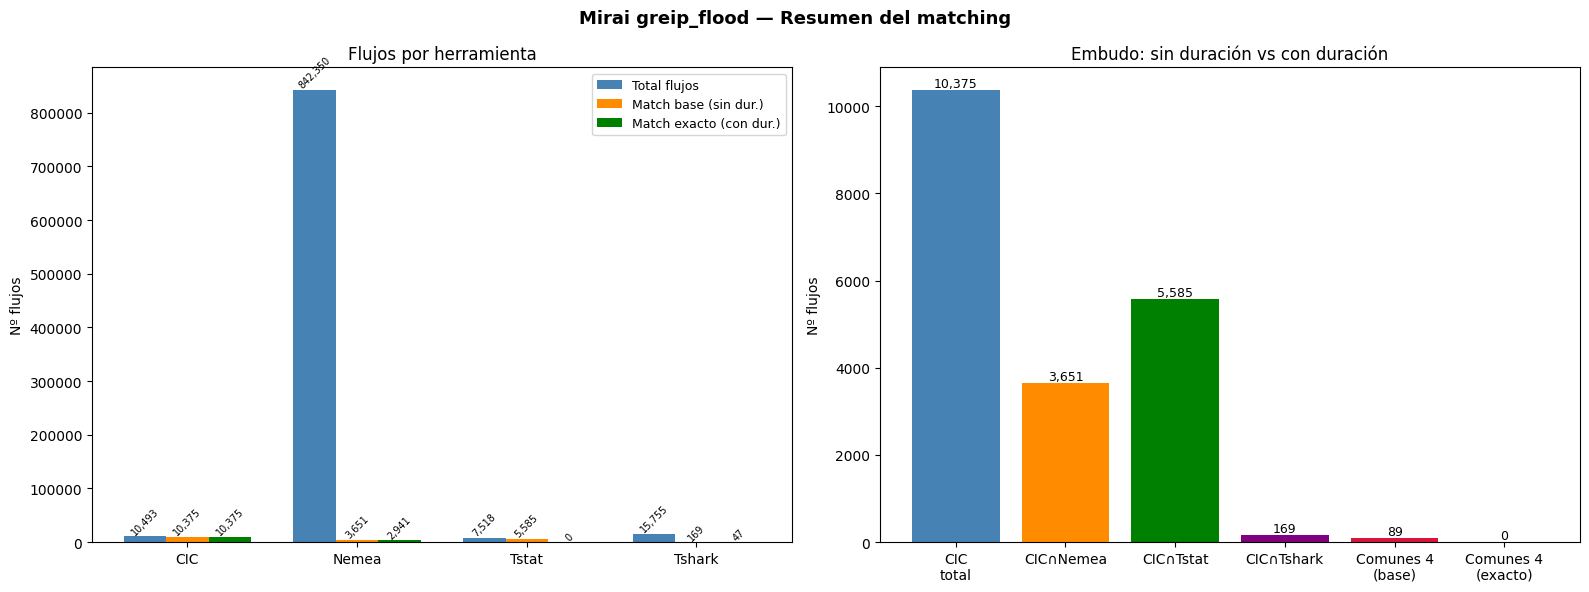

In [21]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mirai greip_flood — Resumen del matching',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
herramientas = ['CIC', 'Nemea', 'Tstat', 'Tshark']
totales = [len(df_cic), len(df_nemea), len(df_tstat_base), len(df_tshark)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, w = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - w, totales, w, label='Total flujos',            color='steelblue')
b2 = ax1.bar(x,     base,    w, label='Match base (sin dur.)',   color='darkorange')
b3 = ax1.bar(x + w, exactos, w, label='Match exacto (con dur.)', color='green')
ax1.set_title('Flujos por herramienta')
ax1.set_ylabel('N\u00ba flujos')
ax1.set_xticks(x); ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:,}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ['CIC\ntotal','CIC\u2229Nemea','CIC\u2229Tstat','CIC\u2229Tshark','Comunes 4\n(base)','Comunes 4\n(exacto)']
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
bars2 = ax2.bar(labels2, values2, color=['steelblue','darkorange','green','purple','crimson','darkred'])
ax2.set_title('Embudo: sin duración vs con duración')
ax2.set_ylabel('N\u00ba flujos')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELDA 5.3 — EXTRACCIÓN FINAL: 4 CSVs
# ============================================================

OUTPUT_DIR = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/Mirai_greip_flood')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLS_AUX_CIC    = ['time_sec','flow_dur_ms','key_base','key_exact']
COLS_AUX_NEMEA  = ['TIME_FIRST_limpio','TIME_LAST_limpio','TIME_FIRST_dt','TIME_LAST_dt',
                   'TIME_FIRST_utc1','TIME_LAST_utc1','SRC_IP_norm','DST_IP_norm',
                   'time_sec','flow_dur_us','flow_dur_ms',
                   'key_base_dir','key_base_inv','key_exact_dir','key_exact_inv','_key']
COLS_AUX_TSTAT  = ['first_utc2','flow_dur_ms','time_sec',
                   'key_base_dir','key_base_inv','_key','proto_num','first_dt']
COLS_AUX_TSHARK = ['start_dt','start_utc2','flow_dur_ms','time_sec',
                   'key_base_dir','key_base_inv','key_exact_dir','key_exact_inv','proto_num','_key']

# ── NEMEA
df_nemea['_key'] = None
m_dir = df_nemea['key_base_dir'].isin(base_4)
m_inv = df_nemea['key_base_inv'].isin(base_4)
df_nemea.loc[m_dir, '_key'] = df_nemea.loc[m_dir, 'key_base_dir']
df_nemea.loc[m_inv & df_nemea['_key'].isna(), '_key'] = df_nemea.loc[m_inv & df_nemea['_key'].isna(), 'key_base_inv']
df_nemea_4 = df_nemea[df_nemea['_key'].isin(base_4)].drop_duplicates(subset=['_key'], keep='first').copy()
claves_nemea_final = set(df_nemea_4['_key'])
df_nemea_4 = df_nemea_4.drop(columns=COLS_AUX_NEMEA, errors='ignore').reset_index(drop=True)
print(f'Nemea:  {len(df_nemea_4):,} filas')

# ── TSTAT
df_tstat_base['_key'] = None
m_dir = df_tstat_base['key_base_dir'].isin(base_4)
m_inv = df_tstat_base['key_base_inv'].isin(base_4)
df_tstat_base.loc[m_dir, '_key'] = df_tstat_base.loc[m_dir, 'key_base_dir']
df_tstat_base.loc[m_inv & df_tstat_base['_key'].isna(), '_key'] = df_tstat_base.loc[m_inv & df_tstat_base['_key'].isna(), 'key_base_inv']
idx_match = df_tstat_base[df_tstat_base['_key'].isin(base_4)].index
idx_match = idx_match[~pd.Series(idx_match).duplicated(keep='first').values]
df_tstat_full = pd.concat([df_tcp_tstat, df_udp_tstat], ignore_index=True)
df_tstat_4 = df_tstat_full.loc[idx_match].copy()
df_tstat_4['_key'] = df_tstat_base.loc[idx_match, '_key'].values
df_tstat_4 = df_tstat_4.drop_duplicates(subset=['_key'], keep='first')
claves_tstat_final = set(df_tstat_4['_key'])
df_tstat_4 = df_tstat_4.drop(columns=COLS_AUX_TSTAT, errors='ignore').reset_index(drop=True)
print(f'Tstat:  {len(df_tstat_4):,} filas')

# ── TSHARK
df_tshark['_key'] = None
m_dir = df_tshark['key_base_dir'].isin(base_4)
m_inv = df_tshark['key_base_inv'].isin(base_4)
df_tshark.loc[m_dir, '_key'] = df_tshark.loc[m_dir, 'key_base_dir']
df_tshark.loc[m_inv & df_tshark['_key'].isna(), '_key'] = df_tshark.loc[m_inv & df_tshark['_key'].isna(), 'key_base_inv']
df_tshark_4 = df_tshark[df_tshark['_key'].isin(base_4)].drop_duplicates(subset=['_key'], keep='first').copy()
claves_tshark_final = set(df_tshark_4['_key'])
df_tshark_4 = df_tshark_4.drop(columns=COLS_AUX_TSHARK, errors='ignore').reset_index(drop=True)
print(f'Tshark: {len(df_tshark_4):,} filas')

# ── CIC
claves_4_real = claves_nemea_final & claves_tstat_final & claves_tshark_final
print(f'\nClaves comunes reales (4 herramientas): {len(claves_4_real):,}')
df_cic_4 = df_cic[df_cic['key_base'].isin(claves_4_real)].copy()
df_cic_4['Flow Duration'] = pd.to_numeric(df_cic_4['Flow Duration'], errors='coerce')
df_cic_4 = df_cic_4.sort_values('Flow Duration', ascending=False)
df_cic_4 = df_cic_4.drop_duplicates(subset=['key_base'], keep='first')
df_cic_4 = df_cic_4.drop(columns=COLS_AUX_CIC, errors='ignore').reset_index(drop=True)
print(f'CIC:    {len(df_cic_4):,} filas')

# ── Guardar
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)

print()
print('=' * 55)
print('RESULTADO FINAL — Mirai greip_flood')
print('=' * 55)
print(f'  CIC:    {len(df_cic_4):>6,} filas x {df_cic_4.shape[1]:>3} columnas')
print(f'  Nemea:  {len(df_nemea_4):>6,} filas x {df_nemea_4.shape[1]:>3} columnas')
print(f'  Tstat:  {len(df_tstat_4):>6,} filas x {df_tstat_4.shape[1]:>3} columnas')
print(f'  Tshark: {len(df_tshark_4):>6,} filas x {df_tshark_4.shape[1]:>3} columnas')
print(f'\n  Guardados en: {OUTPUT_DIR}')
print()
if len(df_cic_4) == len(df_nemea_4) == len(df_tstat_4) == len(df_tshark_4):
    print(f'  \u2713 VERIFICACIÓN CORRECTA — {len(df_cic_4):,} flujos en los 4 CSVs')
else:
    print(f'  \u2717 Algún CSV no coincide \u2192 revisar')
    print(f'     CIC {len(df_cic_4):,} / Nemea {len(df_nemea_4):,} / Tstat {len(df_tstat_4):,} / Tshark {len(df_tshark_4):,}')

In [ ]:
# ============================================================
# CELDA 5.4 — ESTANDARIZAR ETIQUETA A 'Mirai'
# ============================================================

LABEL_MAP = {
    'CIC':    (df_cic_4,    'Label'),
    'Nemea':  (df_nemea_4,  col_etiqueta_nemea),
    'Tshark': (df_tshark_4, 'category'),
    'Tstat':  (df_tstat_4,  'etiqueta'),
}

for nombre, (df, col) in LABEL_MAP.items():
    if col in df.columns:
        antes = df[col].value_counts().to_dict()
        df[col] = 'Mirai'
        print(f'{nombre:8s} | {col:20s} \u2192 antes: {antes}')
        print(f'{"":8s} |                       \u2192 ahora: {df[col].unique().tolist()}')
    else:
        print(f'  \u26a0 {nombre}: columna \'{col}\' no encontrada')

df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print('\u2713 Etiquetas actualizadas y CSVs sobreescritos')